# Max-Pooled Reconstruction-Error Scoring

**New notebook — does not touch any existing pipeline file or retrain anything.**
Loads the already-trained VAE + PCA from the main pipeline unchanged, and
changes only *how the anomaly score is computed from its output*.

**The problem this targets:** the current score is a single MSE computed in
whitened PCA space (26-dim) — effectively a *mean* error across the whole
30-timestep window. Verified directly on a real pod-failure event
(`shippingservice-1`, CC1): memory crashes from 56MB to 1.98MB within about a
minute, a large, completely unmasked signal in the raw data. But that event
lasts ~9 minutes against a 7.5-minute (30-step) window, so many
labeled-anomaly windows contain a *mix* of crashed and normal-looking
timesteps — the crash's contribution to the window's **average** error gets
diluted by the surrounding normal steps. This plausibly explains why
`pod-failure` recall (0.50) is the weakest of the three detectable fault types,
worse than the sustained faults (`memory` 0.76, `cpu` 0.58).

**The fix:** inverse-transform the VAE's reconstruction back through PCA to
the original (30, 7) window shape, compute the squared error **per timestep**,
and pool with **max** (or a high percentile) instead of averaging over all 30
steps at once. A single bad timestep should no longer get averaged away by 29
normal neighbors.

**Honest methodological note, stated up front:** the pooling operator (mean vs.
max vs. percentile) is being compared here using `cc1_test`/`drift_cc2`
performance, because `cc1_val` has zero anomalies and can't be used to pick
between them on F1/recall (only to check false-positive behavior). Comparing
a small number of *fixed, pre-specified* candidates (max, p95, p90) this way is
much lighter than tuning a continuous hyperparameter on the test set, but it's
not perfectly leak-free — flag this explicitly if reporting these results,
rather than presenting the final choice as fully blind.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, joblib, os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score, f1_score,
)

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
WIN_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
MODEL_DIR = os.path.join(BASE, 'models')

ALL_SETS = ['cc1_test', 'drift_cc2']
WINDOW_SIZE, N_FEATURES = 30, 7

class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score_mean(self, x):
        """The ORIGINAL scoring method — mean MSE in whitened PCA space."""
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)
    @torch.no_grad()
    def reconstruct(self, x):
        self.eval(); mu, _ = self.encode(x); return self.decode(mu)

meta  = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
pca_bundle = joblib.load(os.path.join(MODEL_DIR, 'cc1_pca.pkl'))
pca = pca_bundle['pca']
CLIP = meta['clip']

model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()
print('Model + PCA loaded (unchanged from the main pipeline — nothing retrained here).')

Model + PCA loaded (unchanged from the main pipeline — nothing retrained here).


## Step 1 — Load data, compute BOTH old (mean) and new (max-pooled) scores

In [2]:
def compute_scores(X_pca_np):
    """Returns (mean_score, per_timestep_sq_error) for a batch of whitened PCA-space windows.
    per_timestep_sq_error has shape (N, 30) — squared error summed over the 7 original
    features, per timestep, after inverse-transforming both original and reconstruction
    back through PCA into the original (30, 7) window shape."""
    x_t = torch.from_numpy(X_pca_np)
    with torch.no_grad():
        mean_score = model.anomaly_score_mean(x_t).numpy()
        recon_pca = model.reconstruct(x_t).numpy()

    # Inverse-transform BOTH sides through the SAME (already-fitted, unchanged) PCA —
    # this correctly undoes whitening using sklearn's own tested implementation,
    # rather than re-deriving the whitening math by hand.
    x_orig_flat   = pca.inverse_transform(X_pca_np)
    x_recon_flat  = pca.inverse_transform(recon_pca)
    residual_flat = x_orig_flat - x_recon_flat                      # (N, 210)
    residual_window = residual_flat.reshape(-1, WINDOW_SIZE, N_FEATURES)
    per_timestep_sq_error = (residual_window ** 2).sum(axis=2)      # (N, 30)
    return mean_score, per_timestep_sq_error

data = {}
for name in ['cc1_train', 'cc1_val'] + ALL_SETS:
    X = np.clip(np.load(os.path.join(WIN_DIR, f'X_{name}.npy')), -CLIP, CLIP).astype(np.float32)
    y = np.load(os.path.join(WIN_DIR, f'y_{name}.npy'))
    ft = np.load(os.path.join(WIN_DIR, f'ft_{name}.npy'), allow_pickle=True)
    mean_score, per_ts_err = compute_scores(X)
    data[name] = {'y': y, 'ft': ft, 'mean_score': mean_score, 'per_ts_err': per_ts_err}
    print(f'  {name:10s}: {len(y):>7,} windows  |  anomalies: {int(y.sum()):,}')

# Sanity check: the mean score recomputed here must exactly match the original pipeline's saved baseline
assert abs(data['cc1_train']['mean_score'].mean() - meta['mu_train']) < 1e-3
print('\nMean-score sanity check passed (matches original pipeline exactly).')

  cc1_train : 154,198 windows  |  anomalies: 0
  cc1_val   :  21,573 windows  |  anomalies: 0
  cc1_test  :  44,185 windows  |  anomalies: 256
  drift_cc2 :  76,977 windows  |  anomalies: 720

Mean-score sanity check passed (matches original pipeline exactly).


## Step 2 — Candidate pooling operators

Three fixed, pre-specified candidates: **max** (100th percentile), **p95**, **p90**
— compared, not tuned continuously.

In [3]:
POOLING_CANDIDATES = {'max': 100, 'p95': 95, 'p90': 90}

def pool_score(per_ts_err, percentile):
    return np.percentile(per_ts_err, percentile, axis=1)

for name in ['cc1_train', 'cc1_val'] + ALL_SETS:
    for pool_name, q in POOLING_CANDIDATES.items():
        data[name][f'score_{pool_name}'] = pool_score(data[name]['per_ts_err'], q)

print('Pooled scores computed for all candidates.')

Pooled scores computed for all candidates.


## Step 3 — Leak-free thresholds for each scoring method (calibrated from `cc1_val` only)

In [4]:
SCORE_METHODS = ['mean_score', 'score_max', 'score_p95', 'score_p90']

thresholds = {}
for method in SCORE_METHODS:
    t = float(np.percentile(data['cc1_val'][method], 99))
    thresholds[method] = t
    fpr = (data['cc1_val'][method] > t).mean()
    print(f'  {method:12s}: threshold={t:.5f}   flags {fpr*100:.2f}% of cc1_val (target ~1%)')

  mean_score  : threshold=0.09799   flags 1.00% of cc1_val (target ~1%)
  score_max   : threshold=0.29061   flags 1.00% of cc1_val (target ~1%)
  score_p95   : threshold=0.28439   flags 1.00% of cc1_val (target ~1%)
  score_p90   : threshold=0.28259   flags 1.00% of cc1_val (target ~1%)


## Step 4 — Compare: mean (original) vs. max/p95/p90 (new), all four headline metrics

In [5]:
def evaluate(scores, y, threshold):
    pred = (scores > threshold).astype(int)
    return {
        'auc_pr': average_precision_score(y, scores), 'auc_roc': roc_auc_score(y, scores),
        'precision': precision_score(y, pred, zero_division=0), 'recall': recall_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
    }

results = {}
print(f'{"set":12s} {"method":12s} {"PR-AUC":>8s} {"ROC-AUC":>9s} {"F1":>7s} {"Precision":>10s} {"Recall":>8s}')
for name in ALL_SETS:
    results[name] = {}
    for method in SCORE_METHODS:
        r = evaluate(data[name][method], data[name]['y'], thresholds[method])
        results[name][method] = r
        print(f'{name:12s} {method:12s} {r["auc_pr"]:8.4f} {r["auc_roc"]:9.4f} {r["f1"]:7.3f} {r["precision"]:10.3f} {r["recall"]:8.3f}')
    print()

set          method         PR-AUC   ROC-AUC      F1  Precision   Recall
cc1_test     mean_score     0.6014    0.8763   0.618      0.630    0.605
cc1_test     score_max      0.1081    0.8578   0.075      0.044    0.250
cc1_test     score_p95      0.0820    0.8331   0.048      0.028    0.160
cc1_test     score_p90      0.0729    0.8174   0.044      0.026    0.148

drift_cc2    mean_score     0.4089    0.8812   0.276      0.168    0.772
drift_cc2    score_max      0.0478    0.7546   0.079      0.047    0.264
drift_cc2    score_p95      0.0212    0.6562   0.038      0.023    0.122
drift_cc2    score_p90      0.0173    0.6022   0.034      0.020    0.107



## Step 5 — Per-fault-type recall: does `pod-failure` specifically improve?

The whole point of this experiment.

In [6]:
print(f'{"set":12s} {"fault_type":14s} {"n":>5s} {"mean(orig)":>11s} {"max":>7s} {"p95":>7s} {"p90":>7s}')
for name in ALL_SETS:
    ft = data[name]['ft']
    for ftype in sorted({v for v in ft if isinstance(v, str)}):
        mask = ft == ftype
        n = int(mask.sum())
        recs = {}
        for method in SCORE_METHODS:
            pred = (data[name][method] > thresholds[method]).astype(int)
            recs[method] = pred[mask].mean()
        print(f'{name:12s} {ftype:14s} {n:5d} {recs["mean_score"]:11.3f} {recs["score_max"]:7.3f} {recs["score_p95"]:7.3f} {recs["score_p90"]:7.3f}')
    print()

set          fault_type         n  mean(orig)     max     p95     p90
cc1_test     cpu               88       0.580   0.239   0.114   0.091
cc1_test     memory            76       0.763   0.474   0.382   0.368
cc1_test     pod-failure       92       0.500   0.076   0.022   0.022

drift_cc2    cpu              207       0.908   0.372   0.227   0.208
drift_cc2    memory           414       0.713   0.106   0.024   0.019
drift_cc2    pod-failure       99       0.737   0.697   0.313   0.263



## Step 6 — Visualize: per-timestep error trace for the example pod-failure event

Same event referenced in the intro (`shippingservice-1`, CC1) — shows *why*
max-pooling should help, using an actual window from that event if it's
present in `cc1_test`/`drift_cc2` (otherwise the closest available pod-failure
example).

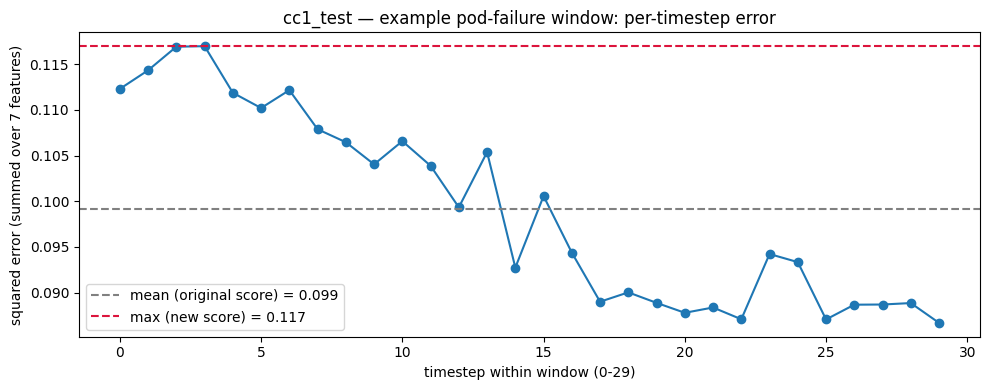

In [7]:
example_set = 'cc1_test' if 'pod-failure' in data['cc1_test']['ft'] else 'drift_cc2'
ft_example = data[example_set]['ft']
pf_idx = np.where(ft_example == 'pod-failure')[0]

if len(pf_idx):
    idx = pf_idx[len(pf_idx) // 2]   # a representative example, not cherry-picked first/best
    per_ts = data[example_set]['per_ts_err'][idx]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(per_ts, marker='o')
    ax.axhline(per_ts.mean(), ls='--', color='gray', label=f'mean (original score) = {per_ts.mean():.3f}')
    ax.axhline(per_ts.max(), ls='--', color='crimson', label=f'max (new score) = {per_ts.max():.3f}')
    ax.set_xlabel('timestep within window (0-29)'); ax.set_ylabel('squared error (summed over 7 features)')
    ax.set_title(f'{example_set} — example pod-failure window: per-timestep error')
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'maxpool_example_window.png'), dpi=120)
    plt.show()
else:
    print(f'No pod-failure windows found in {example_set} to visualize.')

## Step 7 — Save results

In [8]:
save_results = {
    'thresholds': thresholds,
    'results': results,
    'per_fault_recall': {
        name: {
            ftype: {method: float((data[name][method][data[name]['ft'] == ftype] > thresholds[method]).mean())
                    for method in SCORE_METHODS}
            for ftype in sorted({v for v in data[name]['ft'] if isinstance(v, str)})
        }
        for name in ALL_SETS
    },
}
out_path = os.path.join(MODEL_DIR, 'maxpool_scoring_eval.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved -> {out_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\maxpool_scoring_eval.pkl


## How to read this

Compare each `score_*` row against `mean_score` (the original method) in Step 4
and Step 5. If `pod-failure` recall improves substantially under `max`/`p95`/`p90`
without a large precision collapse, this is a real, adoptable improvement —
and the honest way to report it is: "we compared 3 fixed candidate pooling
operators against the original mean-pooling baseline" (not "we tuned the best
possible pooling operator"), consistent with the methodological note in the
intro.